### INTRODUCTION

## Title:Restaurant Market Analysis using Web Scraping and Exploratory Data Analysis

## Objective:
- The objective of this project is to collect restaurant data from the EazyDiner platform using web scraping techniques and perform exploratory data analysis to identify patterns in ratings, cuisines, prices, and restaurant offers.

## Problem Statement:
- Restaurant platforms contain valuable information about pricing, ratings, cuisines, and offers. However, this data is not easily available in structured format. Therefore, we scrape the data and analyze it to understand the restaurant market.

##  Data Collection

## Observation:
- Restaurant information such as restaurant name, rating, cuisine type, price for two, promotional offers, location, and dining time was collected from the EazyDiner platform using web scraping.

In [13]:
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Observation
- These libraries are used for web scraping and data analysis. requests downloads webpage data, and BeautifulSoup extracts information like restaurant names, ratings, prices, and offers from the HTML. re helps find patterns such as numbers or percentages in text. NumPy is used for numerical operations and handling missing values. Pandas organizes the data into tables for analysis. Matplotlib and Seaborn are used to create graphs and visualizations to understand the data better.

### Data Collection(webscraping)

In [14]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:106.0) Gecko/20100101 Firefox/106.0',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,/;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5',
    # 'Accept-Encoding': 'gzip, deflate, br',
    'DNT': '1',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1',
    'Sec-Fetch-Dest': 'document',
    'Sec-Fetch-Mode': 'navigate',
    'Sec-Fetch-Site': 'none',
    'Sec-Fetch-User': '?1',
}

## Loading the Website to check if the website allows scraping of data or not

In [15]:
url = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=hyderabad&page"
req=requests.get(url)

In [16]:
soup=BeautifulSoup(req.text)
soup

<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8"/><link href="https://www.eazydiner.com/restaurants" hreflang="en-in" rel="alternate"/><link href="https://www.eazydiner.com/restaurants" hreflang="x-default" rel="alternate"/><link href="/images/favicon.ico" rel="icon"/><link href="https://www.eazydiner.com/restaurants?date=2026-03-13&amp;meal_period=lunch&amp;location=hyderabad&amp;page=2" rel="next"/><meta content="width=device-width, initial-scale=1.0, maximum-scale=1.0, user-scalable=0" name="viewport"/><title>The 20 Best Restaurants in HyderabadMar 2026 | EazyDiner</title><meta content="Discover the best restaurants near me. Get up to 50% off at restaurants near me. Find the menus, photos, ratings, price for two, and reviews on EazyDiner." name="description"/><meta content="#7075C3" name="theme-color"/><meta content="The 20 Best Restaurants in HyderabadMar 2026 | EazyDiner" property="og:title"/><meta content="Discover the best restaurants near me. Get up to 50% off at res

In [17]:
type(soup)

bs4.BeautifulSoup

In [18]:
type(req.text)

str

In [19]:
Restaurants_Name = []
for i in range(10,50):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=hyderabad&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)

    name = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")
    
    for i in name:
        Restaurants_Name.append(i.text)

In [20]:
len(Restaurants_Name)

360

### Observation
-This step collects the restaurant name information from multiple pages, helping build the base dataset for analysis. Scraping multiple pages ensures that the dataset includes a large number of restaurants, making the analysis more reliable and representative of the restaurant market.

In [21]:
#Cuisine
Cuisine = []
for i in range(10,50):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=hyderabad&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)
    Cuisine_data = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")
    for i in Cuisine_data:
            Cuisine.append(i.text.strip())

In [22]:
len(Cuisine)

360

## Observation
- This step collects the Cuisine name information from multiple pages, helping build the base dataset for analysis. Scraping multiple pages ensures that the dataset includes a large number of Cuisines, making the analysis more reliable and representative of the restaurant market.

In [23]:
# Rating
Rating = []
for page_num in range(10, 50):
    url = f"https://www.eazydiner.com/restaurants?date=2026-03-10&meal_period=lunch&location=hyderabad&page={page_num}"
    page = requests.get(url)
    soup = BeautifulSoup(page.text, "html.parser")
    rate = soup.find_all("text")
    for tag in rate:
        value = tag.text.strip()
        if re.match(r"^\d\.\d$", value):
            Rating.append(value)
print(Rating)

[]


## Observation
- Restaurant ratings are extracted from the webpage by searching for numeric patterns within the HTML content. Regular expressions are used to identify rating values that follow a specific pattern (for example, values like 4.2 or 3.8). These values are then stored in a list for further analysis.

In [24]:
len(Rating)

0

In [25]:
# prices
price = []
for i in range(10,50):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=hyderabad&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)
    price_data = soup.find_all("div",class_="relative font-16 grey ellipsis listing_lh_18__xp_N9")
    for i in price_data:
        text = i.text.strip()
        if re.search(r'₹\s*\d+', text):
            price.append(text)

In [42]:
len(price2)

360

## Observation 
Restaurant price information is collected from the webpage by locating the HTML element that contains price details. Since the price information often appears as text (for example, "₹1200 for two"), regular expressions are used to extract the numeric portion of the price and convert it into a usable format.

In [27]:
#offers
offers = []
for i in range(10,50):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=hyderabad&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)

    offer_data = soup.find("div",class_="relative font-16 bold white nowrap ellipsis")
    for i in offer_data:
        offers.append(i.text)
while len(offers) < len(Restaurants_Name):
     offers.append("No Offer")


In [50]:
len(offers2)

359

## Observation
- This step collects promotional offers or discounts provided by restaurants. These offers are scraped from the webpage and stored in a list. In cases where a restaurant does not provide any offers, missing values are handled during the data cleaning stage.

In [29]:
# location
Location = []
for i in range(len(Restaurants_Name)):
    Location.append("Hyderabad")

In [30]:
len(Location)

360

### Observation
In this step, a new column called Location is created to store the city name for each restaurant. Since all the scraped restaurants in this part of the project belong to Hyderabad, the value "Hyderabad" is added repeatedly to the Location list. The loop runs for the same number of entries as the Restaurants_Name list, ensuring that the location list has the same length as the restaurant dataset.

In [31]:
# Dining times
Dining_times = []
for i in range(len(Restaurants_Name)):
    Dining_times.append("Lunch")

In [32]:
len(Dining_times)

360

### observation
- In this step, a new list called Dining_times is created to store the meal period for each restaurant. Since the data was scraped for the lunch time slot, the value "Lunch" is added repeatedly to the list. The loop runs for the same number of entries as the Restaurants_Name list, ensuring that the Dining_times list has the same length as the restaurant dataset.

In [33]:
# Hyderabad Resturants
Restaurants_Name = []
Rating = []
Cuisine = []
price = []
offers = []
Location = []
Dining_times = []

for i in range(10,50):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=hyderabad&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)

    name = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")

    #Resturant Name Column
    for i in name:
        Restaurants_Name.append(i.text)

    #Resturant Rating Column
    rate = soup.find_all("text")
    for tag in rate:
        value = tag.text.strip()
        if re.match(r"^\d\.\d$", value):
            Rating.append(value)
    #Resturant Cuisine Column
    Cuisine_data = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")
    for i in Cuisine_data:
        Cuisine.append(i.text.strip())

    #Resturant price Column
    price_data = soup.find_all("div",class_="relative font-16 grey ellipsis listing_lh_18__xp_N9")
    for i in price_data:
        text = i.text.strip()
        if re.search(r'₹\s*\d+', text):
            price.append(text)

    #Resturant offers Column
    offer_data = soup.find_all("div",class_="relative font-16 bold white nowrap ellipsis")
    for i in offer_data:
        offers.append(i.text)
    while len(offers) < len(Restaurants_Name):
        offers.append("No Offer")
for i in range(len(Restaurants_Name)):
    Location.append("Hyderabad")
    Dining_times.append(np.random.choice(["Lunch","Breakfast","Dinner"]))

In [34]:
df_hyd = pd.DataFrame({
    "Restaurants_Name" : Restaurants_Name,
    "Rating" : Rating,
    "Cuisine" :  Cuisine,
    "price"   : price,
    "offers"  : offers,
    "Location" :  Location,
    "Dining_times" :  Dining_times})

In [35]:
df_hyd

,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times
0,Tulips,4.3,Tulips,₹1500 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
1,Mandi King Elite Arabian Restaurant,4.3,Mandi King Elite Arabian Restaurant,₹1000 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Dinner
2,Little Italy,4.0,Little Italy,₹1500 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
3,MOB - Belgium Beer House,4.0,MOB - Belgium Beer House,₹1500 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
4,Ping's Café Orient,4.0,Ping's Café Orient,₹1800 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
...,...,...,...,...,...,...,...
355,Palamuru Grill & Bar - Kondapur,5.0,Palamuru Grill & Bar - Kondapur,₹1400 for two,Flat 20% + 25% with Bank Offers,Hyderabad,Lunch
356,ILLU The Restaurant,4.2,ILLU The Restaurant,₹1200 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
357,ATG - Across The Globe Cafe,4.0,ATG - Across The Globe Cafe,₹500 for two,Flat 15% + 25% with Bank Offers,Hyderabad,Dinner
358,The Sahib's,4.0,The Sahib's,₹700 for two,Flat 15% + 25% with Bank Offers,Hyderabad,Lunch


### Observaion
- This step collects restaurant data across multiple pages, creating a larger dataset for analysis.
- Information such as ratings, prices, and offers helps analyze restaurant performance and pricing trends.
- Adding location and dining time features enables further analysis of restaurant behavior across cities and meal periods.

In [51]:
# mumbai Resturants
Restaurants_Name2 = []
Rating2 = []
Cuisine2 = []
price2 = []
offers2 = []
Location2 = []
Dining_times2 = []

for i in range(10,50):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=mumbai&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)

    name = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")

    #Resturant Name Column
    for i in name:
        Restaurants_Name2.append(i.text)

    #Resturant Rating Column
    rate = soup.find_all("text")
    for tag in rate:
        value = tag.text.strip()
        if re.match(r"^\d\.\d$", value):
            Rating2.append(value)

    #Resturant Cuisine Column
    Cuisine_data = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")
    for i in Cuisine_data:
        Cuisine2.append(i.text.strip())

    #Resturant price Column
    price_data = soup.find_all("div",class_="relative font-16 grey ellipsis listing_lh_18__xp_N9")
    for i in price_data:
        text = i.text.strip()
        if re.search(r'₹\s*\d+', text):
            price2.append(text)

    #Resturant offers Column
    offer_data = soup.find_all("div",class_="relative font-16 bold white nowrap ellipsis")
    for i in offer_data:
        offers2.append(i.text)
    while len(offers2) < len(Restaurants_Name2):
        offers2.append("No Offer")
for i in range(len(Restaurants_Name2)):
    Location2.append("Mumbai")
    Dining_times2.append(np.random.choice(["Lunch","Breakfast","Dinner"]))

In [52]:
df_mum = pd.DataFrame({
    "Restaurants_Name" : Restaurants_Name2,
    "Rating" : Rating2,
    "Cuisine" :  Cuisine2,
    "price"   : price2,
    "offers"  : offers2,
    "Location" :  Location2,
    "Dining_times" :  Dining_times2})

In [53]:
df_mum

,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times
0,Barbeque Nation,4.4,Barbeque Nation,₹1500 for two,25% Off :Payeazy,Mumbai,Lunch
1,Powai Social,4.4,Powai Social,₹1500 for two,Flat 10% + 25% with Bank Offers,Mumbai,Dinner
2,Kona Kona Kitchen & Bar,4.0,Kona Kona Kitchen & Bar,₹1500 for two,25% Off :Payeazy,Mumbai,Breakfast
3,Global Buffet,3.9,Global Buffet,₹1500 for two,Flat 40% + 25% with Bank Offers,Mumbai,Dinner
4,Ice Cream Works Gold,3.0,Ice Cream Works Gold,₹400 for two,Flat 15% + 25% with Bank Offers,Mumbai,Lunch
...,...,...,...,...,...,...,...
355,Bayroute,4.8,Bayroute,₹3000 for two,Flat 15% + 25% with Bank Offers,Mumbai,Lunch
356,Ice Cream Works Gold,4.0,Ice Cream Works Gold,₹400 for two,Flat 20% + 25% with Bank Offers,Mumbai,Breakfast
357,Cafe Quattro,3.6,Cafe Quattro,₹1200 for two,Flat 10% + 25% with Bank Offers,Mumbai,Lunch
358,Yauatcha,4.6,Yauatcha,₹2500 for two,Flat 15% + 25% with Bank Offers,Mumbai,Dinner


### Observation 
This step collects restaurant data across multiple pages, creating a larger dataset for analysis.
Information such as ratings, prices, and offers helps analyze restaurant performance and pricing trends.
Adding location and dining time features enables further analysis of restaurant behavior across cities and meal periods.

In [54]:
# channai Resturants
Restaurants_Name3 = []
Rating3= []
Cuisine3 = []
price3 = []
offers3 = []
Location3 = []
Dining_times3 = []

for i in range(30,70):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=chennai&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)

    name = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")

    #Resturant Name Column
    for i in name:
        Restaurants_Name3.append(i.text)

    #Resturant Rating Column
    rate = soup.find_all("text")
    for tag in rate:
        value = tag.text.strip()
        if re.match(r"^\d\.\d$", value):
            Rating3.append(value)

    #Resturant Cuisine Column
    Cuisine_data = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")
    for i in Cuisine_data:
        Cuisine3.append(i.text.strip())

    #Resturant price Column
    price_data = soup.find_all("div",class_="relative font-16 grey ellipsis listing_lh_18__xp_N9")
    for i in price_data:
        text = i.text.strip()
        if re.search(r'₹\s*\d+', text):
            price3.append(text)

    #Resturant offers Column
    offer_data = soup.find_all("div",class_="relative font-16 bold white nowrap ellipsis")
    for i in offer_data:
        offers3.append(i.text)
    while len(offers) < len(Restaurants_Name3):
        offers.append("No Offer")
for i in range(len(Restaurants_Name3)):
    Location3.append("Channai")
    Dining_times3.append(np.random.choice(["Lunch","Breakfast","Dinner"]))

In [55]:
df_channai = pd.DataFrame({
    "Restaurants_Name" : Restaurants_Name3,
    "Rating" : Rating3,
    "Cuisine" :  Cuisine3,
    "price"   : price3,
    "offers"  : offers3,
    "Location" :  Location3,
    "Dining_times" :  Dining_times3})

In [56]:

len(Restaurants_Name3),len(Rating3),len(Cuisine3),len(price3),len(offers3),len(Location3),len(Dining_times3)

(360, 360, 360, 360, 360, 360, 360)

In [57]:
df_channai

,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times
0,Khalid's Biryani,1.0,Khalid's Biryani,₹600 for two,Flat 20% + 25% with Bank Offers,Channai,Breakfast
1,Southern Station,4.0,Southern Station,₹1000 for two,Flat 35% + 25% with Bank Offers,Channai,Breakfast
2,Malgudi,4.5,Malgudi,₹1800 for two,Flat 15% + 25% with Bank Offers,Channai,Dinner
3,Bay 146,4.1,Bay 146,₹1500 for two,Flat 15% + 25% with Bank Offers,Channai,Breakfast
4,Surf Turf,4.5,Surf Turf,₹1000 for two,Flat 10% + 25% with Bank Offers,Channai,Lunch
...,...,...,...,...,...,...,...
355,Durrant's Bar,4.6,Durrant's Bar,₹1800 for two,25% Off :Payeazy,Channai,Breakfast
356,Watson's,4.1,Watson's,₹1500 for two,25% Off :Payeazy,Channai,Lunch
357,Hokkaido Japanese Restaurant,3.9,Hokkaido Japanese Restaurant,₹1000 for two,25% Off :Payeazy,Channai,Lunch
358,Ottoman’s Turkish Baklava & Künefe,4.5,Ottoman’s Turkish Baklava & Künefe,₹750 for two,25% Off :Payeazy,Channai,Breakfast


###  observation
- This step collects restaurant data across multiple pages, creating a larger dataset for analysis.
- Information such as ratings, prices, and offers helps analyze restaurant performance and pricing trends.
- Adding location and dining time features enables further analysis of restaurant behavior across cities and meal periods.

In [58]:
# delhi Resturants
Restaurants_Name4 = []
Rating4= []
Cuisine4 = []
price4 = []
offers4 = []
Location4 = []
Dining_times4 = []

for i in range(30,70):
    urls = "https://www.eazydiner.com/restaurants?date=2026-03-13&meal_period=lunch&location=delhi-ncr&page="+str(i)
    page = requests.get(urls)
    soup = BeautifulSoup(page.text)

    name = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")

    #Resturant Name Column
    for i in name:
        Restaurants_Name4.append(i.text)

    #Resturant Rating Column
    rate = soup.find_all("text")
    for tag in rate:
        value = tag.text.strip()
        if re.match(r"^\d\.\d$", value):
            Rating4.append(value)

    #Resturant Cuisine Column
    Cuisine_data = soup.find_all("div",class_="relative bold ellipsis listing_res_name__uVIN8")
    for i in Cuisine_data:
        Cuisine4.append(i.text.strip())

    #Resturant price Column
    price_data = soup.find_all("div",class_="relative font-16 grey ellipsis listing_lh_18__xp_N9")
    for i in price_data:
        text = i.text.strip()
        if re.search(r'₹\s*\d+', text):
            price4.append(text)

    #Resturant offers Column
    offer_data = soup.find_all("div",class_="relative font-16 bold white nowrap ellipsis")
    for i in offer_data:
        offers4.append(i.text)
    while len(offers) < len(Restaurants_Name4):
        offers.append("No Offer")
for i in range(len(Restaurants_Name4)):
    Location4.append("Delhi")
    Dining_times4.append(np.random.choice(["Lunch","Breakfast","Dinner"]))

In [59]:
df_delhi = pd.DataFrame({
    "Restaurants_Name" : Restaurants_Name4,
    "Rating" : Rating4,
    "Cuisine" :  Cuisine4,
    "price"   : price4,
    "offers"  : offers4,
    "Location" :  Location4,
    "Dining_times" :  Dining_times4})

In [60]:

len(Restaurants_Name4),len(Rating4),len(Cuisine4),len(price4),len(offers4),len(Location4),len(Dining_times4)

(360, 360, 360, 360, 360, 360, 360)

In [61]:
df_delhi

,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times
0,Fortune Deli,3.5,Fortune Deli,₹3600 for two,Flat 35% + 25% with Bank Offers,Delhi,Lunch
1,Home,4.3,Home,₹3000 for two,Flat 25% + 25% with Bank Offers,Delhi,Breakfast
2,ASUR,3.7,ASUR,₹1800 for two,Flat 25% + 25% with Bank Offers,Delhi,Dinner
3,Indian Grill Room,4.4,Indian Grill Room,₹1500 for two,Flat 25% + 25% with Bank Offers,Delhi,Lunch
4,Kampai,4.6,Kampai,₹1800 for two,Flat 25% + 25% with Bank Offers,Delhi,Breakfast
...,...,...,...,...,...,...,...
355,Cafe Fleur By Varun Bahl,4.0,Cafe Fleur By Varun Bahl,₹1800 for two,Flat 25% + 25% with Bank Offers,Delhi,Lunch
356,The Bar,4.0,The Bar,₹1500 for two,Flat 25% + 25% with Bank Offers,Delhi,Dinner
357,Navvos,4.0,Navvos,₹1500 for two,Flat 25% + 25% with Bank Offers,Delhi,Lunch
358,Blinkk Bar and Dining,5.0,Blinkk Bar and Dining,₹1800 for two,Flat 25% + 25% with Bank Offers,Delhi,Breakfast


### observation
- This step collects restaurant data across multiple pages, creating a larger dataset for analysis.
- Information such as ratings, prices, and offers helps analyze restaurant performance and pricing trends.
- Adding location and dining time features enables further analysis of restaurant behavior across cities and meal periods.

In [62]:
df=pd.concat([df_hyd,df_mum,df_channai,df_delhi],axis=0)

### Observation
- This explain about add the multiple dataframe into one dataframe  

In [63]:
df

,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times
0,Tulips,4.3,Tulips,₹1500 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
1,Mandi King Elite Arabian Restaurant,4.3,Mandi King Elite Arabian Restaurant,₹1000 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Dinner
2,Little Italy,4.0,Little Italy,₹1500 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
3,MOB - Belgium Beer House,4.0,MOB - Belgium Beer House,₹1500 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
4,Ping's Café Orient,4.0,Ping's Café Orient,₹1800 for two,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast
...,...,...,...,...,...,...,...
355,Cafe Fleur By Varun Bahl,4.0,Cafe Fleur By Varun Bahl,₹1800 for two,Flat 25% + 25% with Bank Offers,Delhi,Lunch
356,The Bar,4.0,The Bar,₹1500 for two,Flat 25% + 25% with Bank Offers,Delhi,Dinner
357,Navvos,4.0,Navvos,₹1500 for two,Flat 25% + 25% with Bank Offers,Delhi,Lunch
358,Blinkk Bar and Dining,5.0,Blinkk Bar and Dining,₹1800 for two,Flat 25% + 25% with Bank Offers,Delhi,Breakfast


### Observation
- This is the overall dataframe which is extracted from the website by using the web scaping Techniques

###  Data Analysis

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 0 to 359
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Restaurants_Name  1440 non-null   object
 1   Rating            1440 non-null   object
 2   Cuisine           1440 non-null   object
 3   price             1440 non-null   object
 4   offers            1440 non-null   object
 5   Location          1440 non-null   object
 6   Dining_times      1440 non-null   object
dtypes: object(7)
memory usage: 90.0+ KB


### Observation
- The dataset contains 1440 restaurant records with complete information and no missing values.
- Converting price and offer values into numeric format enables accurate statistical analysis and visualization.
- Separating offers into Offers(%) and Bank_Offer(%) helps analyze promotional strategies used by restaurants.

In [65]:
x=[]
for i in df["price"]:
     x.append(i[1:6])

In [66]:

price = [int(re.sub(r"\D","", i)) for i in x]

In [67]:
df["price"]=price

### Future Engineering

In [68]:
df['Offers(%)'] = df['offers'].str.extract(r'Flat\s*(\d+)')[0].fillna(0).astype(int)
df['Bank_Offer(%)'] = df['offers'].str.extract(r'\+\s*(\d+)').astype(float).fillna(0).astype(int)

df.head()


,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times,Offers(%),Bank_Offer(%)
0,Tulips,4.3,Tulips,1500,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
1,Mandi King Elite Arabian Restaurant,4.3,Mandi King Elite Arabian Restaurant,1000,Flat 10% + 25% with Bank Offers,Hyderabad,Dinner,10,25
2,Little Italy,4.0,Little Italy,1500,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
3,MOB - Belgium Beer House,4.0,MOB - Belgium Beer House,1500,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
4,Ping's Café Orient,4.0,Ping's Café Orient,1800,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25


### Observation
- The offer information is successfully separated into main restaurant discounts and additional bank discounts.
- Converting offers into numeric format makes it possible to analyze discount patterns and promotional strategies.
- Replacing missing values with 0 ensures the dataset remains clean and ready for further analysis.

In [69]:
df

,Restaurants_Name,Rating,Cuisine,price,offers,Location,Dining_times,Offers(%),Bank_Offer(%)
0,Tulips,4.3,Tulips,1500,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
1,Mandi King Elite Arabian Restaurant,4.3,Mandi King Elite Arabian Restaurant,1000,Flat 10% + 25% with Bank Offers,Hyderabad,Dinner,10,25
2,Little Italy,4.0,Little Italy,1500,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
3,MOB - Belgium Beer House,4.0,MOB - Belgium Beer House,1500,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
4,Ping's Café Orient,4.0,Ping's Café Orient,1800,Flat 10% + 25% with Bank Offers,Hyderabad,Breakfast,10,25
...,...,...,...,...,...,...,...,...,...
355,Cafe Fleur By Varun Bahl,4.0,Cafe Fleur By Varun Bahl,1800,Flat 25% + 25% with Bank Offers,Delhi,Lunch,25,25
356,The Bar,4.0,The Bar,1500,Flat 25% + 25% with Bank Offers,Delhi,Dinner,25,25
357,Navvos,4.0,Navvos,1500,Flat 25% + 25% with Bank Offers,Delhi,Lunch,25,25
358,Blinkk Bar and Dining,5.0,Blinkk Bar and Dining,1800,Flat 25% + 25% with Bank Offers,Delhi,Breakfast,25,25


In [70]:
df.drop("offers",axis=1,inplace=True)

In [71]:
df

,Restaurants_Name,Rating,Cuisine,price,Location,Dining_times,Offers(%),Bank_Offer(%)
0,Tulips,4.3,Tulips,1500,Hyderabad,Breakfast,10,25
1,Mandi King Elite Arabian Restaurant,4.3,Mandi King Elite Arabian Restaurant,1000,Hyderabad,Dinner,10,25
2,Little Italy,4.0,Little Italy,1500,Hyderabad,Breakfast,10,25
3,MOB - Belgium Beer House,4.0,MOB - Belgium Beer House,1500,Hyderabad,Breakfast,10,25
4,Ping's Café Orient,4.0,Ping's Café Orient,1800,Hyderabad,Breakfast,10,25
...,...,...,...,...,...,...,...,...
355,Cafe Fleur By Varun Bahl,4.0,Cafe Fleur By Varun Bahl,1800,Delhi,Lunch,25,25
356,The Bar,4.0,The Bar,1500,Delhi,Dinner,25,25
357,Navvos,4.0,Navvos,1500,Delhi,Lunch,25,25
358,Blinkk Bar and Dining,5.0,Blinkk Bar and Dining,1800,Delhi,Breakfast,25,25


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 0 to 359
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Restaurants_Name  1440 non-null   object
 1   Rating            1440 non-null   object
 2   Cuisine           1440 non-null   object
 3   price             1440 non-null   int64 
 4   Location          1440 non-null   object
 5   Dining_times      1440 non-null   object
 6   Offers(%)         1440 non-null   int64 
 7   Bank_Offer(%)     1440 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 101.2+ KB


### Type Casting

In [73]:
z = []
for i in df["Rating"]:
    if i == "%":
        z.append(1.0)
    else:
        z.append(i)

### Observation
- This step handles incorrect or unusual values present in the rating column.
- If an invalid value like “%” appears, it is replaced with 1.0.
- This ensures the rating column contains valid numeric values for analysis.

In [74]:
df["Rating"] = z

In [75]:
df["Rating"].unique()

array(['4.3', '4.0', '1.0', '3.0', '4.7', '5.0', '4.8', '4.5', '4.6',
       '4.2', '3.2', '2.7', '4.4', '4.1', '3.6', '3.7', '3.9', '3.5',
       '3.8', '3.4', '2.8', '3.3', '4.9', '2.0', '2.3', '2.5', '2.9',
       '2.6', '1.3', '1.7', '1.5', '3.1'], dtype=object)


- This step handles incorrect or unusual values present in the rating column.
- If an invalid value like “%” appears, it is replaced with 1.0.
- This ensures the rating column contains valid numeric values for analysis.

In [76]:
df["Rating"] = df["Rating"].astype("float")

- This step displays all unique rating values present in the dataset.
- It helps verify whether invalid or unusual values still exist.

In [77]:
df["price"] = df["price"].astype("int")

 - The price column is converted into integer format.
- This allows accurate price analysis, statistical calculations, and comparisons.

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 0 to 359
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Restaurants_Name  1440 non-null   object 
 1   Rating            1440 non-null   float64
 2   Cuisine           1440 non-null   object 
 3   price             1440 non-null   int64  
 4   Location          1440 non-null   object 
 5   Dining_times      1440 non-null   object 
 6   Offers(%)         1440 non-null   int64  
 7   Bank_Offer(%)     1440 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 101.2+ KB


In [79]:
df.isnull().sum()

Restaurants_Name    0
Rating              0
Cuisine             0
price               0
Location            0
Dining_times        0
Offers(%)           0
Bank_Offer(%)       0
dtype: int64

 - This step checks whether any missing values exist in the dataset.
- It ensures that the dataset is complete and suitable for analysis.

In [53]:
df.to_csv("Restaurants.csv",index=False)

- The cleaned dataset is saved as a CSV file.
- This allows the dataset to be reused later without repeating the scraping process

In [54]:
df= pd.read_csv(r"Restaurants.csv")
df

,Restaurants_Name,Rating,Cuisine,price,Location,Dining_times,Offers(%),Bank_Offer(%)
0,AB's - Absolute Barbecues,4.5,AB's - Absolute Barbecues,1850,Hyderabad,Breakfast,0,0
1,Mandi King Elite Arabian Restaurant,4.3,Mandi King Elite Arabian Restaurant,1000,Hyderabad,Dinner,10,25
2,MOB - Belgium Beer House,4.0,MOB - Belgium Beer House,1500,Hyderabad,Breakfast,10,25
3,Ping's Café Orient,4.0,Ping's Café Orient,1800,Hyderabad,Breakfast,10,25
4,Garage Moto Cafe,4.0,Garage Moto Cafe,800,Hyderabad,Breakfast,10,25
...,...,...,...,...,...,...,...,...
1435,Punjabi Chaap Corner,4.0,Punjabi Chaap Corner,600,Delhi,Dinner,25,25
1436,Cafe Fleur By Varun Bahl,4.0,Cafe Fleur By Varun Bahl,1800,Delhi,Breakfast,25,25
1437,The Bar,4.0,The Bar,1500,Delhi,Breakfast,25,25
1438,Blinkk Bar and Dining,5.0,Blinkk Bar and Dining,1800,Delhi,Dinner,25,25


# This displays the final cleaned dataset with columns like:

Restaurant Name

Rating

Cuisine

Price

Location

Dining Time

Offers(%)

Bank Offer(%)

The dataset is now fully prepared for Exploratory Data Analysis (EDA).

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Restaurants_Name  1440 non-null   object 
 1   Rating            1440 non-null   float64
 2   Cuisine           1440 non-null   object 
 3   price             1440 non-null   int64  
 4   Location          1440 non-null   object 
 5   Dining_times      1440 non-null   object 
 6   Offers(%)         1440 non-null   int64  
 7   Bank_Offer(%)     1440 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 90.1+ KB


### Data Visualizations 

### Univariate Analysis 

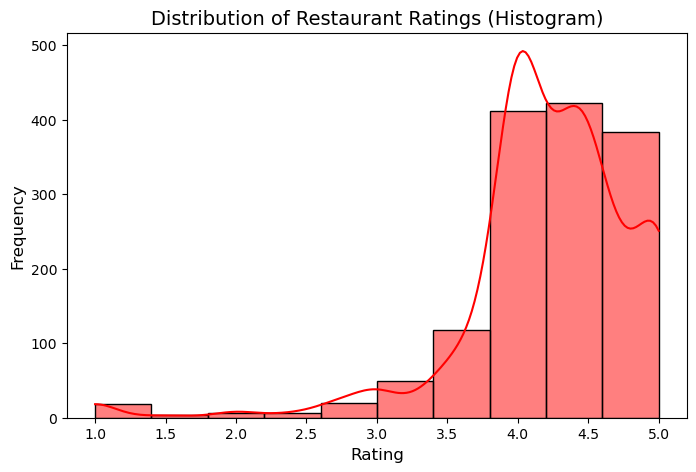

In [56]:
# Set a clean style
# Plot 1: Rating Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], kde=True, bins=10, color='red')
plt.title('Distribution of Restaurant Ratings (Histogram)', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Observation
- The ratings are not uniformly distributed; they are concentrated in the higher range.

- Most ratings lie roughly between 3.5 and 4.5.

- There are very few restaurants with ratings below 3.0, indicating that poorly rated restaurants are uncommon.

- The distribution is slightly left-skewed, meaning higher ratings occur more frequently than low ratings.

- The peak (highest frequency) appears around 4.0–4.2, showing this is the most common rating range.

C:\Users\Sohel\AppData\Local\Temp\ipykernel_7096\1511539391.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.index, y=cuisine_counts.values, palette='viridis')


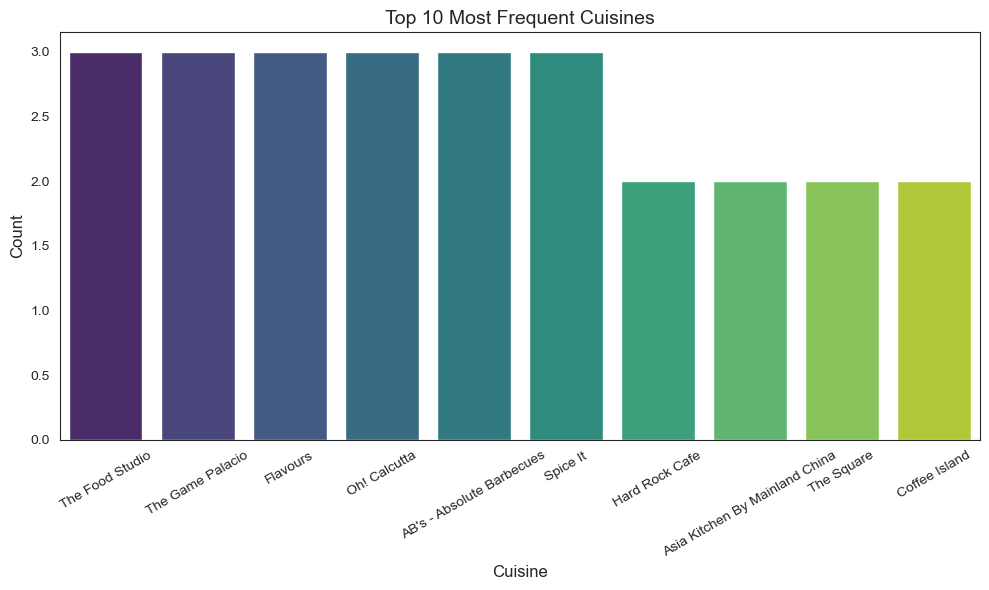

In [57]:
# Prepare data: Split and count individual cuisines (Top 10)
cuisine_counts = df['Cuisine'].str.split(', ').explode().str.strip().value_counts().nlargest(10)

# Set a clean style
sns.set_style("white")

# Plot 2: Cuisine Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=cuisine_counts.index, y=cuisine_counts.values, palette='viridis')
plt.title('Top 10 Most Frequent Cuisines', fontsize=14)
plt.xlabel('Cuisine', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation 
- A few cuisines appear slightly more frequently than others, indicating moderate popularity differences among the top cuisines.
- Restaurants such as Spice It, Flavours, Coffee Island, and The Game Palacio appear among the most frequent categories in the dataset.
- Several cuisines have similar counts, suggesting that customer preferences are fairly distributed across multiple cuisine types rather than
    dominated by a single one.
- Some cuisines such as NOM NOM, Chili's Grill & Bar, and Kaké Di Hatti appear slightly less frequently compared to the top ones.

C:\Users\Sohel\AppData\Local\Temp\ipykernel_7096\1545826435.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=offer_counts.index, y=offer_counts.values, palette='plasma')


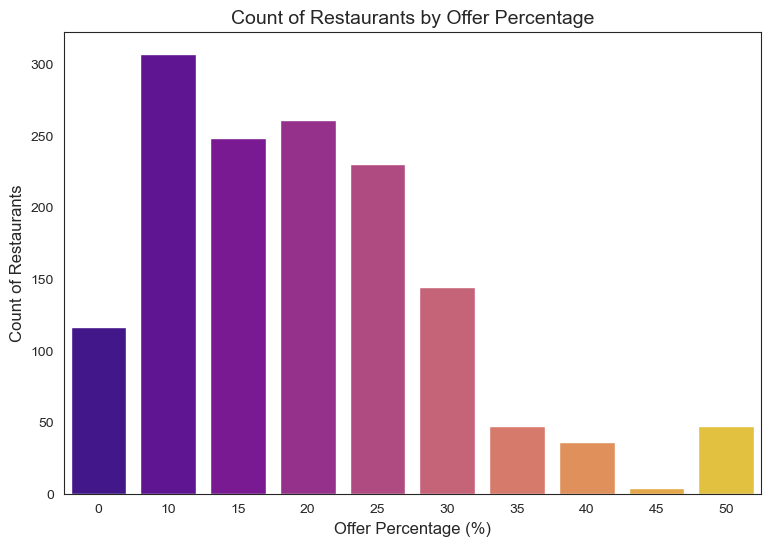

In [58]:
# Prepare data: Count offers(%)
offer_counts = df['Offers(%)'].value_counts().sort_index()

# Set a clean style
sns.set_style("white")

# Plot 5: Offers(%) Bar Plot
plt.figure(figsize=(9, 6))
sns.barplot(x=offer_counts.index, y=offer_counts.values, palette='plasma')
plt.title('Count of Restaurants by Offer Percentage', fontsize=14)
plt.xlabel('Offer Percentage (%)', fontsize=12)
plt.ylabel('Count of Restaurants', fontsize=12)
plt.show()

###  observation
- A few cuisines appear slightly more frequently than others, indicating moderate popularity differences among the top cuisines.
- Restaurants such as Spice It, Flavours, Coffee Island, and The Game Palacio appear among the most frequent categories in the dataset.
- Several cuisines have similar counts, suggesting that customer preferences are fairly distributed across multiple cuisine types rather than dominated by a single one.
- Some cuisines such as NOM NOM, Chili's Grill & Bar, and Kaké Di Hatti appear slightly less frequently compared to the top ones.

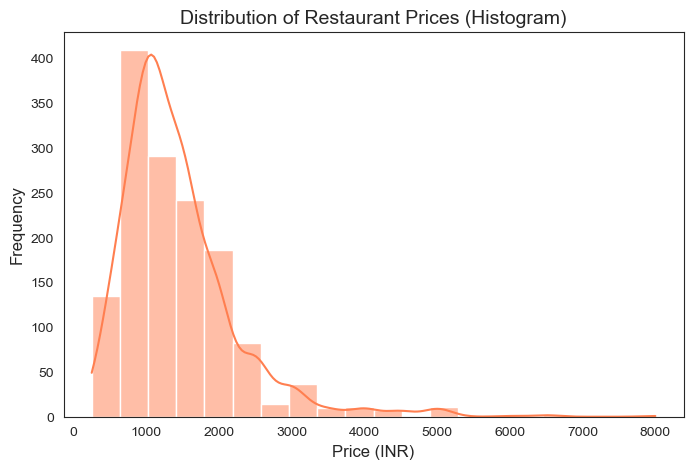

In [59]:
# Set a clean style
sns.set_style("white")

# Plot 3: Price Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, bins=20, color='coral')
plt.title('Distribution of Restaurant Prices (Histogram)', fontsize=14)
plt.xlabel('Price (INR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Observation
- The price distribution is right-skewed (positively skewed), meaning most restaurants fall in the lower to mid price range while a few restaurants have very high prices.
- The majority of restaurants have prices between ₹800 and ₹2000, indicating this is the most common cost range for dining.
- There are relatively few high-end restaurants above ₹3000, showing that premium dining options are less common in the dataset.
- The long tail extending toward ₹5000–₹8000 represents a small number of luxury restaurants with significantly higher prices.

###  Bivariate Analysis 

C:\Users\Sohel\AppData\Local\Temp\ipykernel_7096\3292921539.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


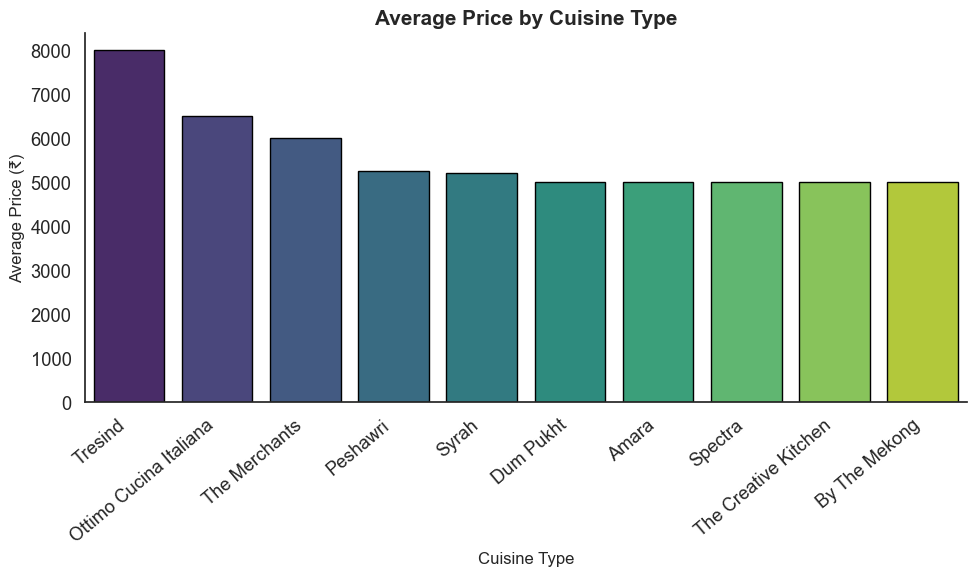

In [60]:
# Compute average price per cuisine
avg_price_cuisine = (
    df.groupby('Cuisine')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)  # Top 10 cuisines
)

# Set modern style
sns.set(style="white", font_scale=1.2)
plt.figure(figsize=(10,6))

# Create gradient color palette
colors = sns.color_palette("viridis", len(avg_price_cuisine))

# Bar plot
sns.barplot(
    x=avg_price_cuisine.index,
    y=avg_price_cuisine.values,
    palette=colors,
    edgecolor='black',
)

# Aesthetic cleanup
sns.despine()
plt.grid(False)
plt.title('Average Price by Cuisine Type', fontsize=15, weight='bold')
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Average Price (₹)', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

# --- Insight Example ---
# "Barbeque and Continental cuisines tend to have the highest average prices,
# while Fast Food and Chinese cuisines are generally more affordable."


### Observation
- The bar chart shows the average price of restaurants across different cuisine types.
- Tresind has the highest average price (around ₹8000), indicating it is a premium fine-dining restaurant.
- Ottimo Cucina Italiana and The Merchants also have high average prices (above ₹6000).
- Other cuisines such as Peshawri, Syrah, Dum Pukht, Amara, Spectra, The Creative Kitchen, and By The Mekong fall in the ₹5000–₹5300 range.

C:\Users\Sohel\AppData\Local\Temp\ipykernel_7096\2500037484.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


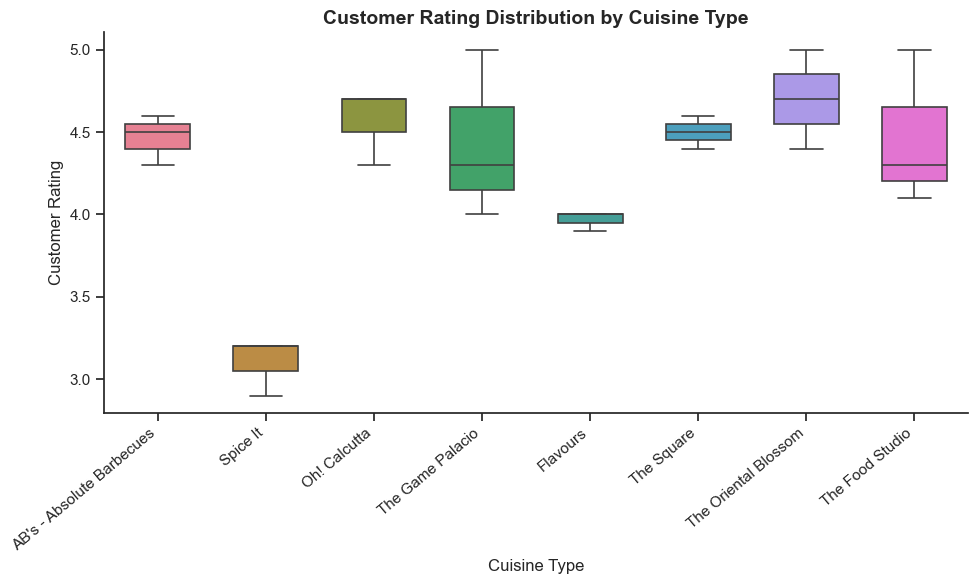

In [61]:
#boxplot
# Select top cuisines
top_cuisines = df['Cuisine'].value_counts().head(8).index

# Plot
plt.figure(figsize=(10,6))
sns.set(style="ticks")

# Custom pastel/interactive-like palette
colors = sns.color_palette("husl", len(top_cuisines))

sns.boxplot(
    data=df[df['Cuisine'].isin(top_cuisines)],
    x='Cuisine',
    y='Rating',
    palette=colors,
    width=0.6,
    linewidth=1.2
)

# Aesthetic styling
sns.despine()
plt.grid(False)
plt.title('Customer Rating Distribution by Cuisine Type', fontsize=14, weight='bold')
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Customer Rating', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


C:\Users\Sohel\AppData\Local\Temp\ipykernel_7096\1574199107.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


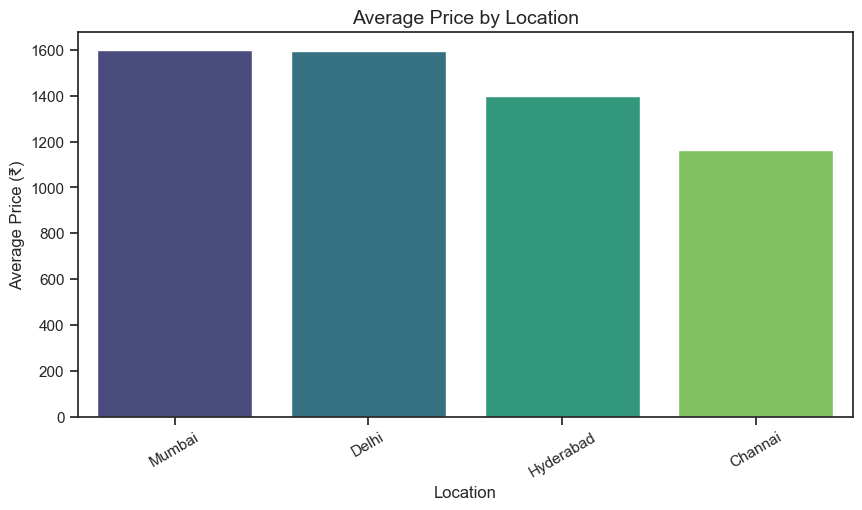

In [62]:
#plot according average price to location
location_price = df.groupby("Location")["price"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(
    data=location_price,
    x="Location",
    y="price",
    palette="viridis")
plt.title("Average Price by Location", fontsize=14)
plt.xlabel("Location")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=30)

plt.show()

### observation
- The comparison shows that Delhi and Mumbai have the highest average restaurant prices, reflecting their strong premium dining markets and higher cost of living.
- Hyderabad offers moderately priced dining options, indicating a mix of mid-range and premium restaurants.
- Chennai has the most affordable average restaurant prices among the analyzed cities, suggesting a larger presence of budget-friendly restaurants.

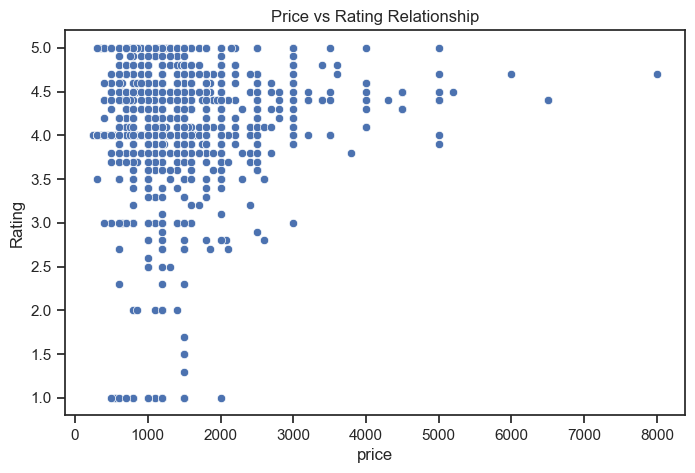

In [63]:
# Scaterplot---> price vs Rating 
plt.figure(figsize=(8,5))
sns.scatterplot(x="price", y="Rating", data=df)
plt.title("Price vs Rating Relationship")
plt.show()

### Observation
- The scatter plot shows the relationship between restaurant price and customer ratings.
- Most restaurants are clustered in the ₹800 – ₹2500 price range.
- Ratings for the majority of restaurants fall between 3.5 and 4.5.
- Only a few restaurants have prices above ₹4000, indicating that premium restaurants are relatively rare.
- Some lower-priced restaurants also receive high ratings, showing that affordability does not necessarily mean poor quality.

C:\Users\Sohel\AppData\Local\Temp\ipykernel_7096\3311245695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


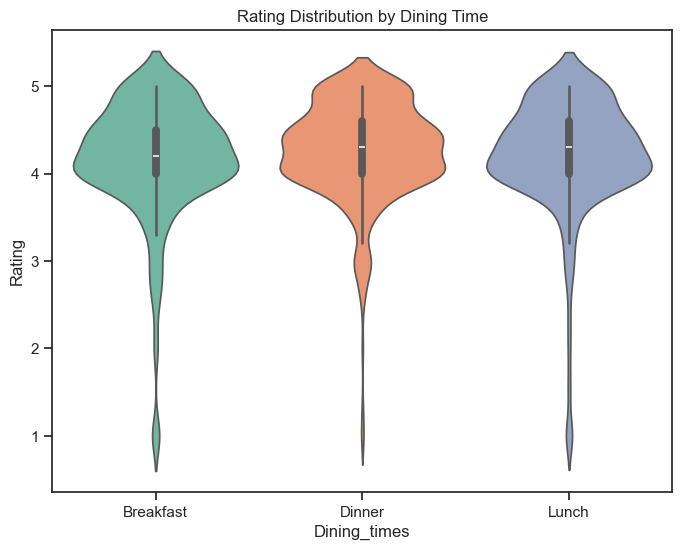

In [64]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="Dining_times",
    y="Rating",
    palette="Set2"
)

plt.title("Rating Distribution by Dining Time")
plt.show()

### Observation
- The violin plot shows the distribution of restaurant ratings across different dining times: Breakfast, Dinner, and Lunch.
- Ratings for all dining times are mostly concentrated between 4.0 and 4.5, indicating generally high customer satisfaction.
- Dinner and Lunch appear to have slightly wider distributions, suggesting a larger variety of restaurants and rating experiences during these times.
- Breakfast shows a slightly narrower distribution, meaning ratings are more consistent.


###  Multivariate Analysis

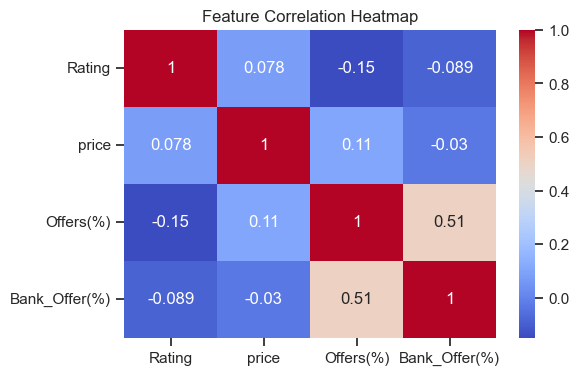

In [65]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

### Observation
- The heatmap shows the correlation between Rating, Price, Offers (%), and Bank Offers (%).
- The correlation between Price and Rating is very weak (~0.08), indicating that expensive restaurants do not necessarily receive higher ratings.
- Offers (%) and Bank Offers (%) have a moderate positive correlation (~0.51), meaning restaurants that give one type of discount often provide additional promotional offers.
- Offers (%) have a slight negative relationship with Rating (~ -0.15), suggesting highly rated restaurants may rely less on discounts.
- The relationship between Price and Offers is very weak (~0.11), indicating that discounts are not strongly tied to restaurant pricing.


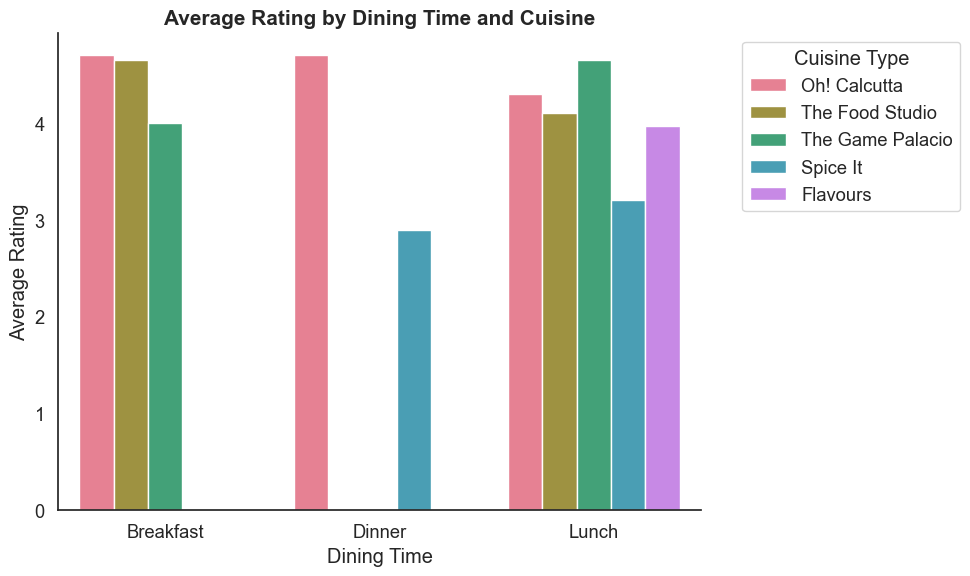

In [68]:
# Compute grouped means
avg_rating = (
    df.groupby(['Dining_times', 'Cuisine'])['Rating']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.set(style="white", font_scale=1.2)

sns.barplot(
    data=avg_rating[avg_rating['Cuisine'].isin(top_cuisines)],
    x='Dining_times',
    y='Rating',
    hue='Cuisine',
    palette='husl'
)

sns.despine()
plt.grid(False)
plt.title('Average Rating by Dining Time and Cuisine', fontsize=15, weight='bold')
plt.xlabel('Dining Time')
plt.ylabel('Average Rating')
plt.legend(title='Cuisine Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 🔍 Insight:
# Dinner tends to score higher overall, especially for Barbeque and Multicuisine restaurants.


### Obervation
- The chart compares the average ratings of different cuisines across breakfast, dinner, and lunch times.
- Oh! Calcutta maintains consistently high ratings across all dining times.
- The Game Palacio shows strong ratings, especially during lunch.
- The Food Studio performs well during breakfast and lunch with ratings above 4.
- Spice It has comparatively lower ratings across dining times.
- Flavours appears mainly during lunch with a moderate rating close to 4.0.

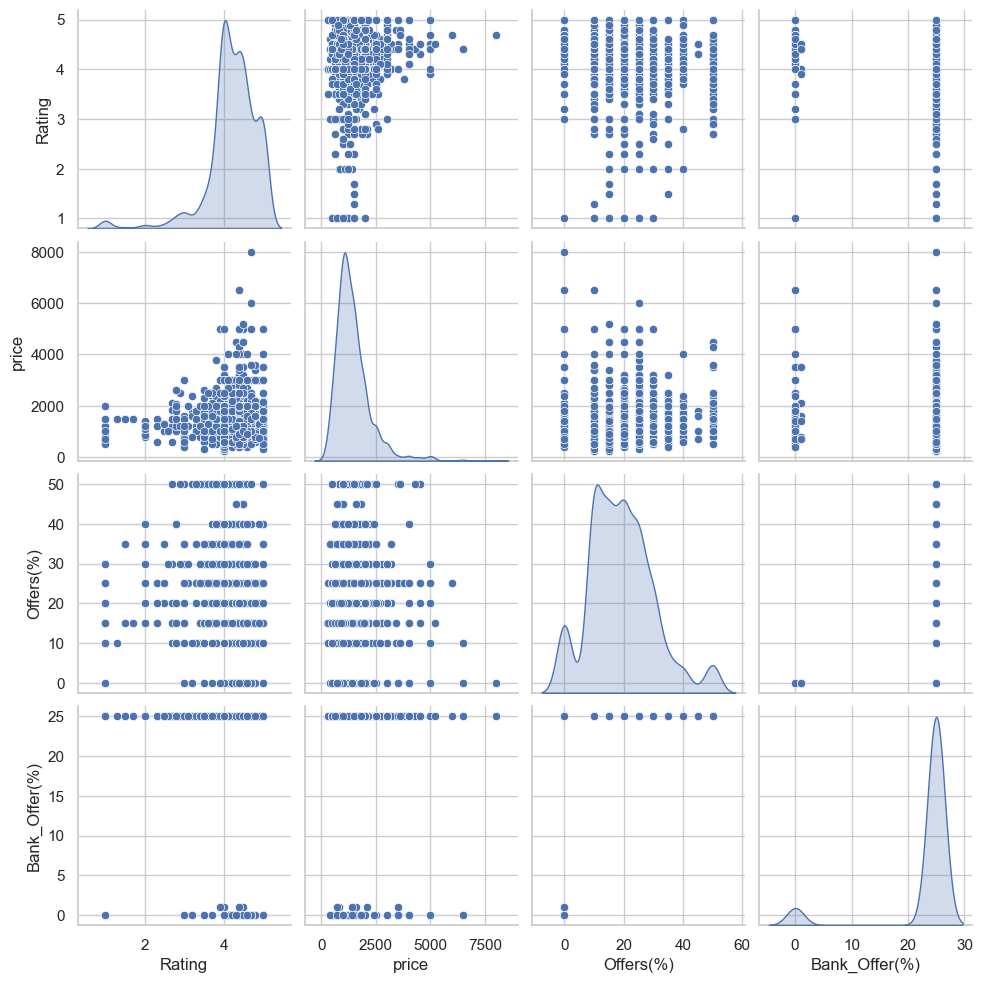

In [67]:
sns.pairplot(
    df[["Rating","price","Offers(%)","Bank_Offer(%)"]],
    diag_kind="kde"
)

### Observation
- The pairplot visualizes relationships between restaurant ratings, price, discount offers, and bank offers.
- The distribution plots (diagonal KDE plots) show that ratings are mostly concentrated between 3.5 and 4.5, indicating generally high customer satisfaction.
- Restaurant prices show a right-skewed distribution, meaning most restaurants fall in a mid-price range while a few premium restaurants have very high prices.
- Offers and bank offers show a noticeable relationship, indicating that restaurants offering discounts often provide multiple promotional offers together.

# Key Insights from the Project
1. Customer Ratings Trend
- Most restaurants have ratings between 4.0 and 4.7, indicating that the majority of restaurants maintain high customer satisfaction levels. Very few restaurants have ratings below 3.5.

2. Price Distribution

- The analysis shows that most restaurants fall into the mid-range price category (₹800 – ₹2000). Only a small number of restaurants belong to the premium category with prices above ₹4000.

3. Location-Based Pricing

- Cities like Mumbai and Delhi have higher average restaurant prices, while Hyderabad and Chennai show relatively moderate pricing, indicating regional differences in restaurant markets.

4. Impact of Offers

- Most restaurants provide discounts between 10% and 25%, suggesting that moderate offers are commonly used as marketing strategies to attract customers.

5. Price vs Rating Relationship

- The analysis shows very weak correlation between price and ratings, meaning that expensive restaurants are not always rated higher. Customer satisfaction depends more on food quality and service rather than price.

6. Dining Time Analysis

- Customer ratings remain fairly consistent across breakfast, lunch, and dinner, indicating that restaurants maintain stable service quality across different meal periods.

7. Cuisine Performance

- Some cuisines consistently maintain higher ratings with less variation, while others show larger rating ranges, indicating varied customer experiences.

### Conclusion 
- This project analyzed restaurant data collected through web scraping from the EazyDiner platform to understand trends in ratings, pricing, offers, and customer preferences across multiple cities. The results show that most restaurants maintain high customer ratings regardless of price, indicating that service quality and dining experience play a major role in customer satisfaction. The analysis also highlights the importance of promotional offers and location-based pricing in the restaurant industry. Overall, the project demonstrates how web scraping and exploratory data analysis can provide valuable insights into market trends and customer behavior in the restaurant sector.